### This notebook creates Risk Maps for microcuencas in Peru using the results of the impact chain calculations from the BD_ClimateRiesgo_IKI sql database

**Created:** 12/26/2025 by Sophia Bakar (sbakar@rti.org)

**Project #:** 0219481  

**Last modified:** 12/26/2025 by Sophia Bakar
 
**Status:** in progress

**QA Status:** reviewed by  

**Original Script Stored at:** Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\

**Objective:**   

**Compatibility:** 

**Packages:** numpy, pandas, geopandas, sqlite3, matplotlib 

**Further documentation:**  
 
**Inputs:** shapefile of subbasins, BD_RiesgoClimatico_IKI sql database

**Outputs:** 
 
**Assumptions:** 
 
**Future work:** 
 
**Notes:** This script queries the IKI Climate Risk SQL database to get the risk values for a particular impact chain for each COMID. Maps are generate using the Peru subbasins shapefile merged by COMID with the results from the impact chains. Maps are created for the baseline scenario, future scenario, and the percent change between the scenarios.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import sqlite3
import os
import unicodedata
from matplotlib.colors import ListedColormap

In [2]:
# Connect to the SQLite database
# user = 'sgilson'
#db_path = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db'
db_path = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db"
conn = sqlite3.connect(db_path)

In [3]:
#subbasins_shapefile = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/Peru_AHD_with_districts.shp'
subbasins_shapefile = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\GIS_WaterALLOC_General\Peru_AHD_with_districts.shp"
subbasins_gdf = gpd.read_file(subbasins_shapefile).set_index('COMID').to_crs('WGS84')

In [4]:
subbasins_gdf['Cuenca'].unique()

array(['Cuenca Ilave', 'Cuenca Ramis', 'Cuenca Ica', 'Cuenca Mantaro',
       'Cuenca Santa', 'Cuenca Chicama', 'Cuenca Moche',
       'Cuenca Chancay-Lambayeque', 'Cuenca Olmos', 'Cuenca Cascajal',
       'Cuenca Piura', 'Cuenca Sama', 'Cuenca Nanay', 'Cuenca Zarumilla',
       'Cuenca Tumbes', 'Cuenca Chira', 'Cuenca Alto Marañon',
       'Cuenca Mayo', 'Cuenca Viru', 'Cuenca Huamansaña',
       'Cuenca Lacramarca', 'Cuenca Nepeña', 'Cuenca Urubamba',
       'Cuenca Chancay - Huaral', 'Cuenca Chillon', 'Cuenca Rimac',
       'Cuenca Lurin', 'Cuenca Pampas', 'Cuenca Camana',
       'Cuenca Quilca - Vitor - Chili', 'Cuenca Locumba',
       'Cuenca Caplina', 'Intercuenca 13155'], dtype=object)

In [5]:
cuencas_to_plot = ["Cuenca Tumbes", "Cuenca Zarumilla", "Cuenca Nanay", "Cuenca Ramis", "Cuenca Ilave"] # add more as needed

use_all_cuencas = False

In [6]:
# Parameters
impact_chains = [1,2,6,7,8,9,10,11,12,13,14,15,16,17]
#output_path = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\RiskMaps_Results'    
output_path = r"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\RiskMaps_Results"
# Uncomment the following lines to automatically get all impact chains from the table in the future
# query = "SELECT DISTINCT IcID FROM ImpactChain_Results"
# impact_chains = [row[0] for row in conn.execute(query).fetchall()]

In [7]:
# Get impact chain metadata from database
impact_chains_df = pd.read_sql("SELECT IcID, Name, Sector FROM ImpactChains", conn)
# Create a dictionary: IcID -> (Name, Sector)
ic_metadata = dict(zip(impact_chains_df['IcID'], zip(impact_chains_df['Name'], impact_chains_df['Sector'])))


In [8]:
scenario_df = pd.read_sql("""
    SELECT DISTINCT r.WaScnID, ws.WaScnName
    FROM ImpactChain_Results r
    JOIN WaScenarios ws ON r.WaScnID = ws.WaScnID
    ORDER BY r.WaScnID
""", conn)

scenario_names = dict(zip(scenario_df["WaScnID"], scenario_df["WaScnName"]))

print("Available WaScenarios found in ImpactChain_Results:")
print(scenario_df)

Available WaScenarios found in ImpactChain_Results:
   WaScnID                 WaScnName
0        1          CC_CMIP6_85_2050
1        3           Linea_Base_2020
2        4  Linea_Base_2020_Embalses


In [9]:
def clean_name(name):
    """
    Make folder-safe names (remove accents, spaces → _).
    """
    name = unicodedata.normalize('NFKD', name).encode('ascii', 'ignore').decode()
    return name.replace(" ", "_")

In [10]:
# Risk classification settings
risk_bins = [-float('inf'), 0.2501, 0.50, 0.75, 1]  # include anything <0 in 'Bajo'
risk_labels = ['Bajo', 'Medio', 'Alto', 'Muy alto']
risk_colors = ['green', 'yellow', 'orange', 'red']  # Low → High

def classify_risk_fixed(series):
    """
    Classify a continuous risk series into fixed categories.
    Values below 0 are also 'Bajo'.
    """
    return pd.cut(
        series,
        bins=risk_bins,
        labels=risk_labels,
        include_lowest=True,
        right=True
    )


In [11]:
# Function to query risk values for a given impact chain and scenario
def get_results_df(impact_chain_id, wascn_id):
    query = """
    SELECT COMID, Peligro, Exposicion, Vulnerabilidad, Riesgo
    FROM ImpactChain_Results
    WHERE IcID = ? AND WaScnID = ?
    """
    df = pd.read_sql_query(query, conn, params=(impact_chain_id, wascn_id))
    df.set_index("COMID", inplace=True)
    return df

In [ ]:
# # Function to plot and save risk map
# def plot_risk_map(gdf, column, title, output_file, cmap='viridis', vmin=None, vmax=None):
#     fig, ax = plt.subplots(1, 1, figsize=(10, 10))
#     gdf.plot(column=column, ax=ax, legend=True, cmap=cmap, vmin=vmin, vmax=vmax)
#     ax.set_title(title)
#     ax.set_axis_off()
#     plt.tight_layout()
#     plt.savefig(output_file, dpi=300)
#     plt.close()

In [17]:
def add_north_arrow(ax, loc_x=0.92, loc_y=0.92, size=0.05):
    """
    Add a compact north arrow to a matplotlib axis.
    """
    ax.annotate(
        "",
        xy=(loc_x, loc_y),
        xytext=(loc_x, loc_y - size),
        arrowprops=dict(
            facecolor="black",
            edgecolor="black",
            width=3,
            headwidth=10,
            headlength=10
        ),
        xycoords=ax.transAxes
    )

    ax.text(
        loc_x,
        loc_y + 0.015,
        "N",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
        transform=ax.transAxes
    )


In [ ]:
def add_scale_bar_meters(ax,gdf_m,segment_km=50,n_segments=2,loc_x=0.05,loc_y=0.05,height_frac=0.01,label_offset_frac=0.25):

    """
    Proper scale bar for projected CRS in meters (e.g., UTM).
    Example: 0–50–100 km
    """

    segment_m = segment_km * 1000
    total_m = segment_m * n_segments

    bounds = gdf_m.total_bounds  # (minx, miny, maxx, maxy) in meters
    map_width = bounds[2] - bounds[0]
    map_height = bounds[3] - bounds[1]

    x_start = bounds[0] + map_width * loc_x
    y_start = bounds[1] + map_height * loc_y
    bar_height = map_height * height_frac

    # Draw segments
    for i in range(n_segments):
        ax.add_patch(
            plt.Rectangle(
                (x_start + i * segment_m, y_start),
                segment_m,
                bar_height,
                facecolor="black" if i % 2 == 0 else "white",
                edgecolor="black",
                linewidth=0.8
            )
        )

    # Outline
    ax.add_patch(
        plt.Rectangle(
            (x_start, y_start),
            total_m,
            bar_height,
            fill=False,
            edgecolor="black",
            linewidth=1
        )
    )

    label_y = y_start - bar_height * 1.8

    # Labels
    ax.text(x_start, label_y, "0", ha="center", va="top", fontsize=9)
    ax.text(x_start + segment_m, label_y, f"{segment_km}", ha="center", va="top", fontsize=9)

    ax.text(
        x_start + total_m + segment_m * label_offset_frac,
        label_y,
        f"{segment_km * n_segments} km",
        ha="left",
        va="top",
        fontsize=9
    )

In [ ]:
def plot_pev_1x3_classified(gdf,title,output_file,risk_cmap,plot_crs="EPSG:32718"):
    
    """
    1 row x 3 cols:
    - PeligroClass
    - ExposicionClass
    - VulnerabilidadClass
    """

    gdf_plot = gdf.to_crs(plot_crs)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes = axes.flatten()

    panels = [
        ("Peligro", "PeligroClass"),
        ("Exposición", "ExposicionClass"),
        ("Vulnerabilidad", "VulnerabilidadClass"),
    ]

    for ax, (panel_title, col) in zip(axes, panels):

        gdf_plot.plot(
            column=col,
            ax=ax,
            legend=True,
            cmap=risk_cmap,
            missing_kwds={"color": "lightgrey", "label": "Sin datos"}
        )

        gdf_plot.boundary.plot(ax=ax, color="lightgrey", linewidth=0.4)

        ax.set_title(panel_title, fontsize=12)
        ax.set_axis_off()

        add_north_arrow(ax)
        add_scale_bar_meters(ax, gdf_plot)

    fig.suptitle(title, fontsize=16, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.savefig(output_file, dpi=300)
    plt.close()


In [ ]:
def plot_risk_single_classified(
    gdf,
    title,
    output_file,
    risk_cmap,
    plot_crs="EPSG:32718"
):
    """
    Single map:
    - RiskClass
    """

    gdf_plot = gdf.to_crs(plot_crs)

    fig, ax = plt.subplots(1, 1, figsize=(10, 10))

    gdf_plot.plot(
        column="RiskClass",
        ax=ax,
        legend=True,
        cmap=risk_cmap,
        missing_kwds={"color": "lightgrey", "label": "Sin datos"}
    )

    gdf_plot.boundary.plot(ax=ax, color="lightgrey", linewidth=0.4)

    ax.set_title(title, fontsize=14)
    ax.set_axis_off()

    add_north_arrow(ax)
    add_scale_bar_meters(ax, gdf_plot)

    plt.tight_layout()
    plt.savefig(output_file, dpi=300)
    plt.close()


In [15]:
# Get Spanish impact chain metadata from DB
impact_chains_df_es = pd.read_sql("SELECT IcID, Name_ES, Sector_ES FROM ImpactChains",conn)

# IcID -> (Spanish Name, Spanish Sector)
ic_metadata_es = dict(zip(impact_chains_df_es["IcID"],zip(impact_chains_df_es["Name_ES"], impact_chains_df_es["Sector_ES"])))

KeyboardInterrupt: 

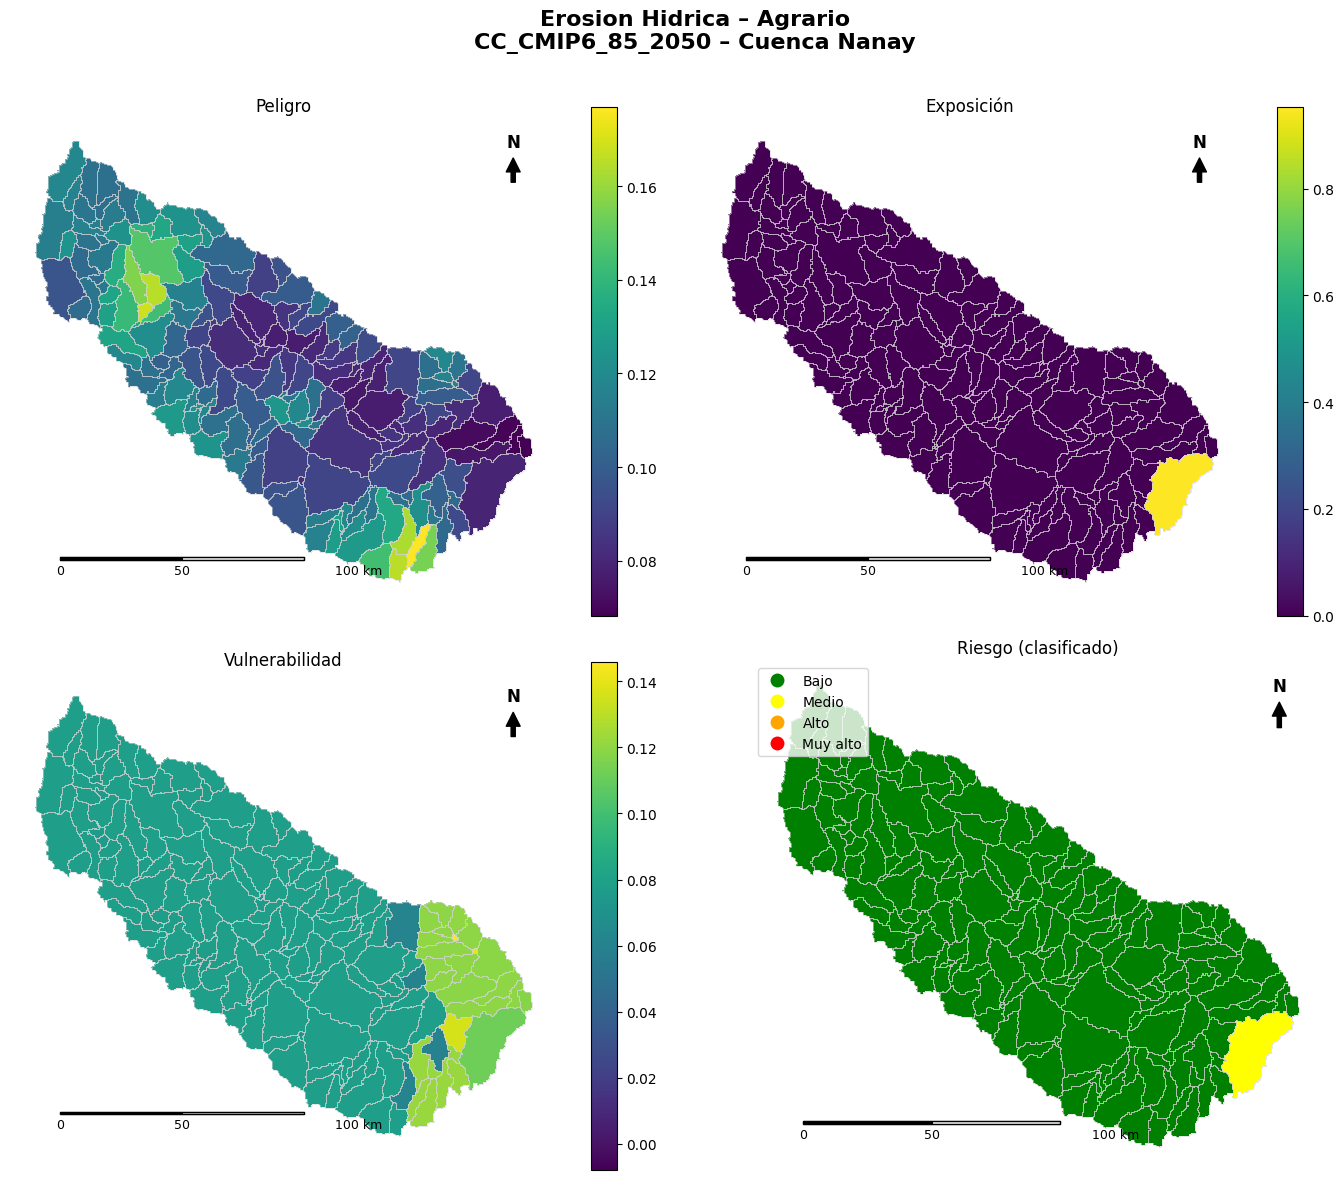

In [18]:
for ic in impact_chains:

    name, sector = ic_metadata_es.get(ic, ("Unknown", "Unknown"))

    for cuenca in cuencas_to_plot if not use_all_cuencas else subbasins_gdf["Cuenca"].unique():

        cuenca_clean = clean_name(cuenca)

        cuenca_output_path = os.path.join(output_path, f"{cuenca_clean}")
        os.makedirs(cuenca_output_path, exist_ok=True)

        cuenca_gdf = subbasins_gdf[subbasins_gdf["Cuenca"] == cuenca]

        if cuenca_gdf.empty:
            print(f"⚠️ Cuenca sin datos (geometría vacía): {cuenca}")
            continue

        # Loop through WaScnID scenarios found in results
        for wascn_id, wascn_label in scenario_names.items():

            results_df = get_results_df(ic, wascn_id)

            if results_df.empty:
                print(f"⚠️ Sin resultados en DB: IcID={ic}, WaScnID={wascn_id}")
                continue

            results_gdf = cuenca_gdf.join(results_df, how="left")

            if results_gdf.empty:
                print(f"⚠️ Resultado vacío después del join: IcID={ic}, WaScnID={wascn_id}, Cuenca={cuenca}")
                continue

            # classify ONLY the final risk map
            results_gdf["RiskClass"] = classify_risk_fixed(results_gdf["Riesgo"])

            # skip if everything is NaN for all numeric panels
            cols_needed = ["Peligro", "Exposicion", "Vulnerabilidad", "Riesgo"]
            if results_gdf[cols_needed].isna().all().all():
                print(f"⚠️ All NaN: IcID={ic}, WaScnID={wascn_id}, Cuenca={cuenca}")
                continue

            output_file = os.path.join(
                cuenca_output_path,
                f"IC{ic}_WaScn{wascn_id}_ALL.png"
            )

            title = (
                f"{name} – {sector}\n"
                f"{wascn_label} – {cuenca}"
            )

            try:
                plot_ic_4panel_map(
                    gdf=results_gdf,
                    title=title,
                    output_file=output_file,
                    risk_cmap=ListedColormap(risk_colors),
                    continuous_cmap="viridis"
                )
            except Exception as e:
                print(f"❌ Plotting error: IcID={ic}, WaScnID={wascn_id}, Cuenca={cuenca}")
                print(f"   -> {type(e).__name__}: {e}")
                continue

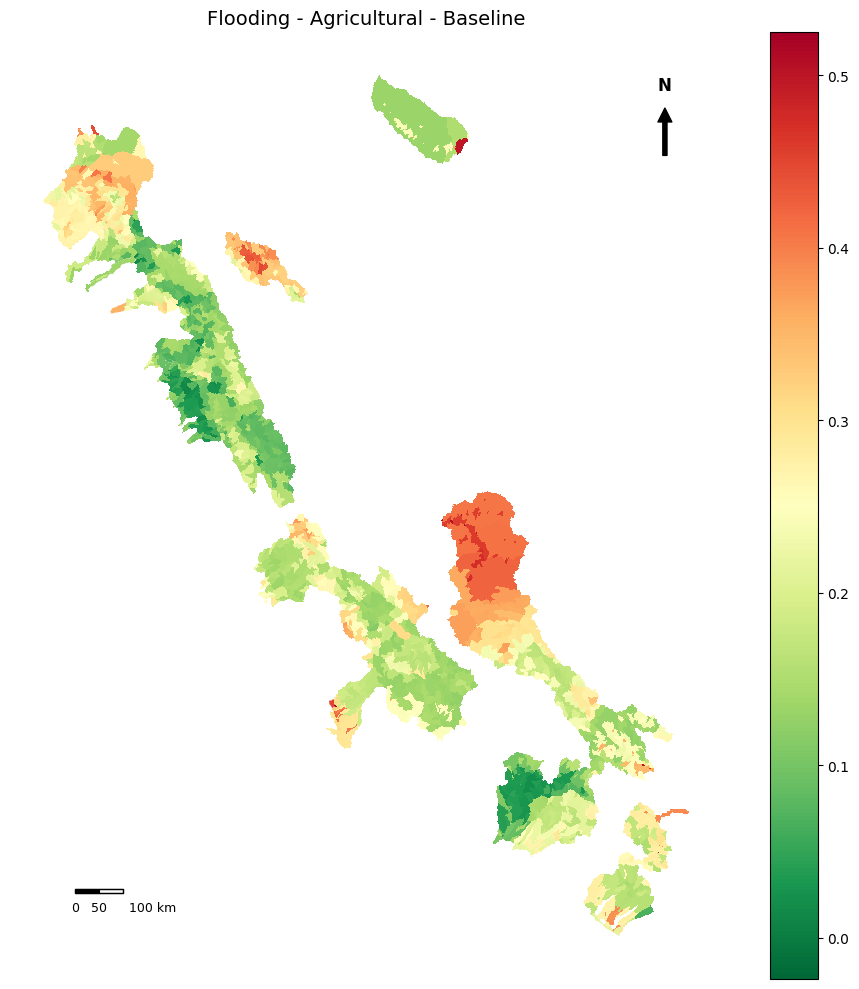

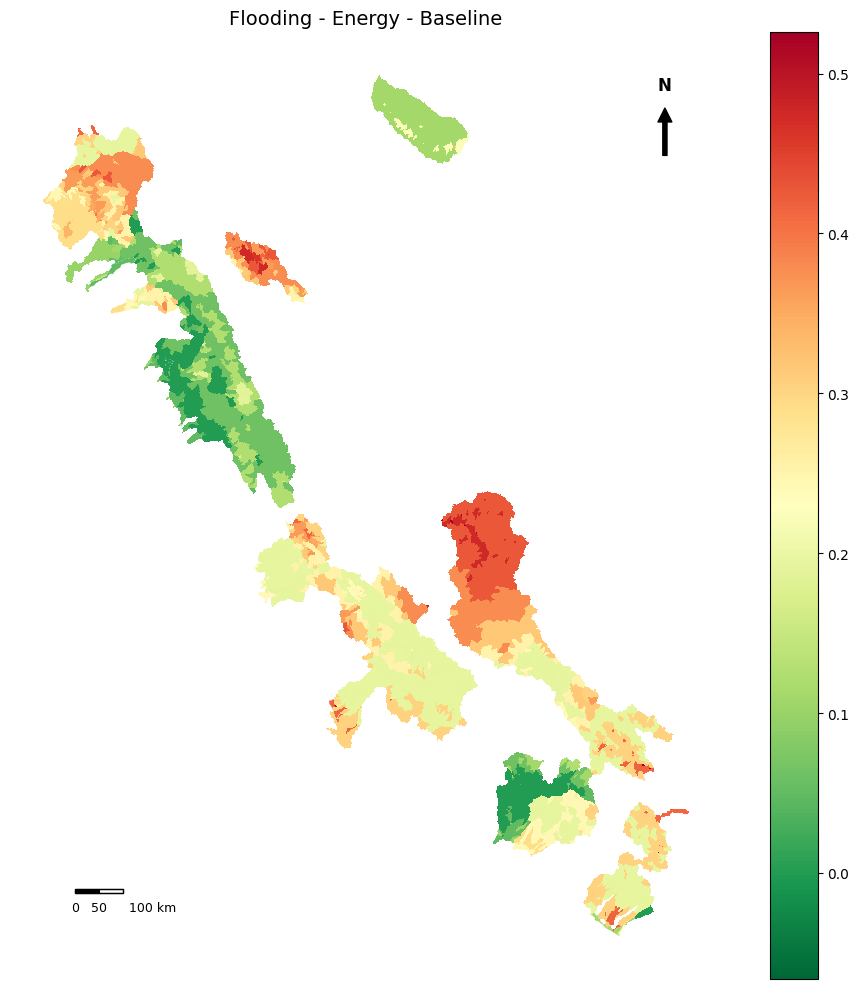

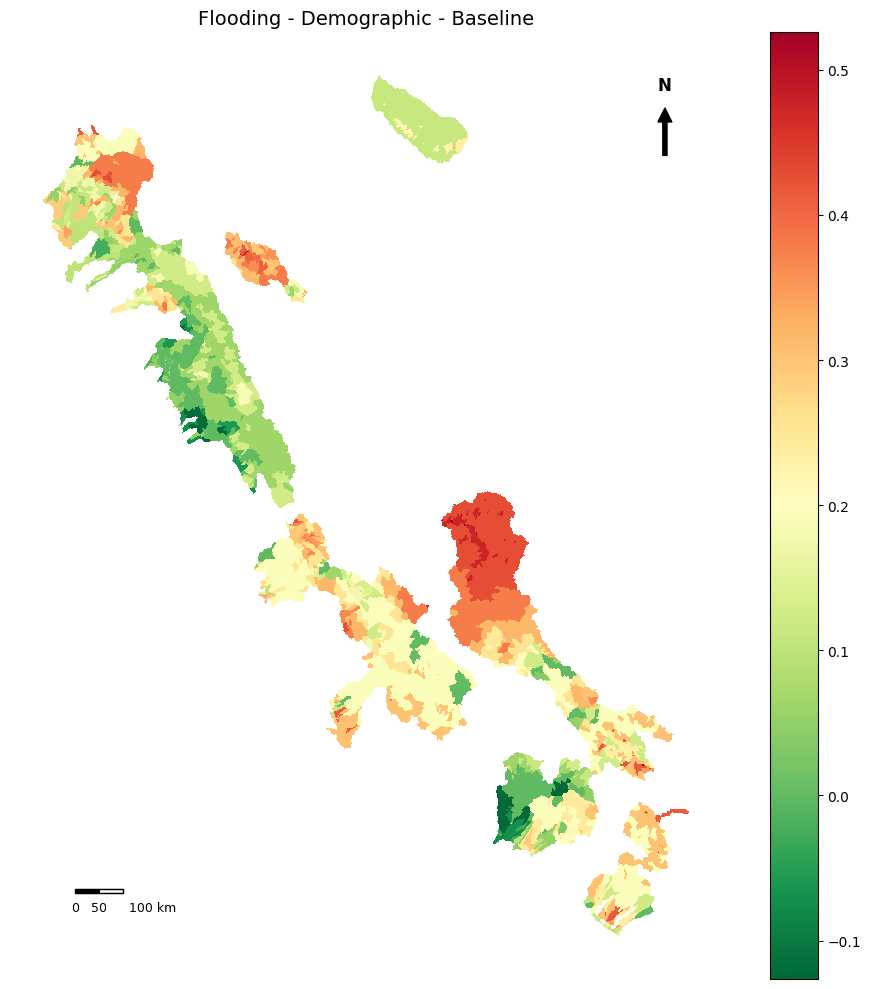

In [39]:
## FOR TESTING
impact_chains = [9, 10, 11]

for ic in impact_chains:
    # Query baseline risk
    baseline_df = get_risk_df(ic, baseline_scnid)

    # Merge with geometry
    baseline_gdf = subbasins_gdf.join(baseline_df, how='left')

    # Get metadata for title
    name, sector = ic_metadata.get(ic, ("Unknown", "Unknown"))
    scenario_name = scenario_names.get(baseline_scnid, str(baseline_scnid))

    # Plot continuous risk
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    baseline_gdf.plot(
        column='Riesgo',
        ax=ax,
        legend=True,
        cmap='RdYlGn_r',  # green=low, red=high
        missing_kwds={'color': 'lightgrey', 'label': 'No data'}
    )

    # Updated title
    ax.set_title(f"{name} - {sector} - {scenario_name}", fontsize=14)
    ax.set_axis_off()

    # Add cartographic elements
    add_north_arrow(ax)
    add_scale_bar(ax, baseline_gdf)

    plt.tight_layout()
    plt.show()


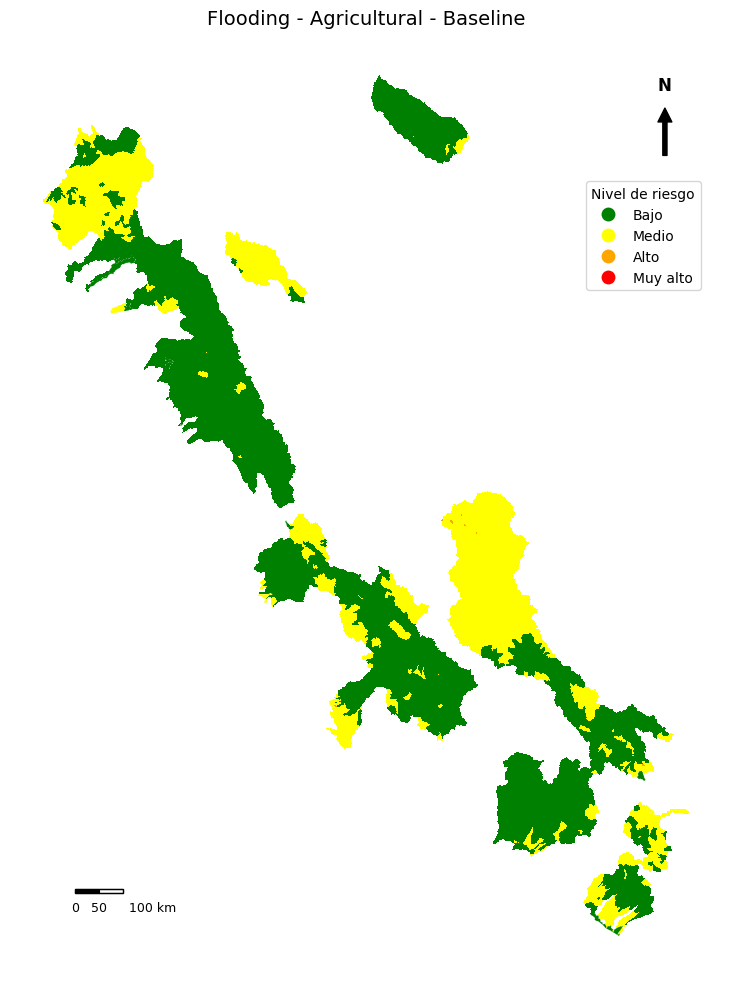

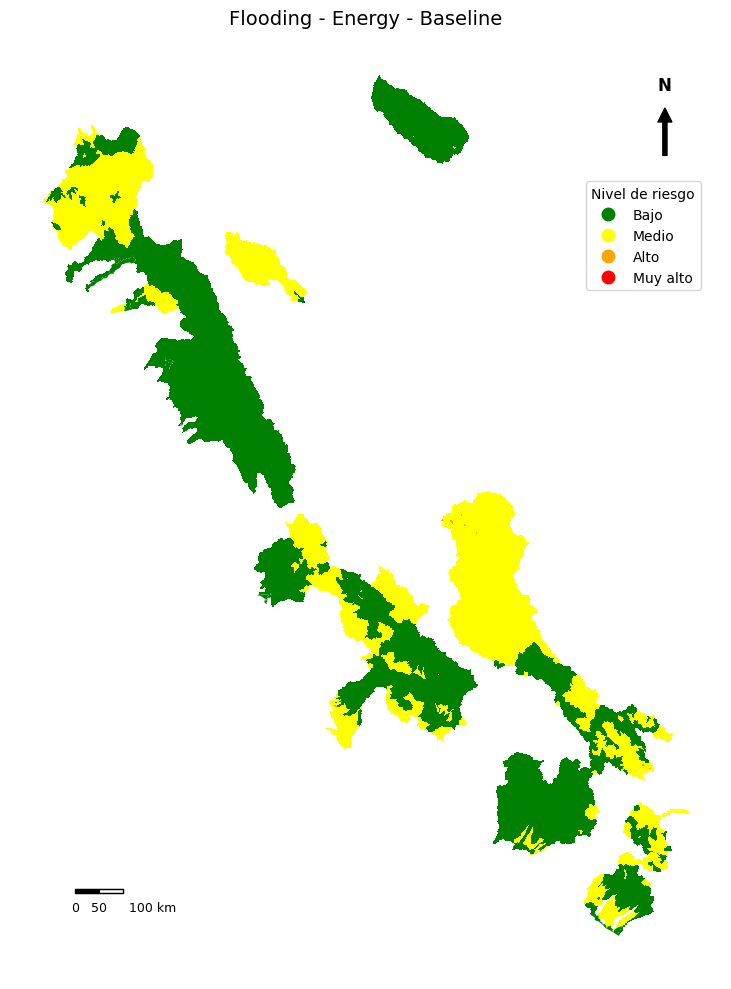

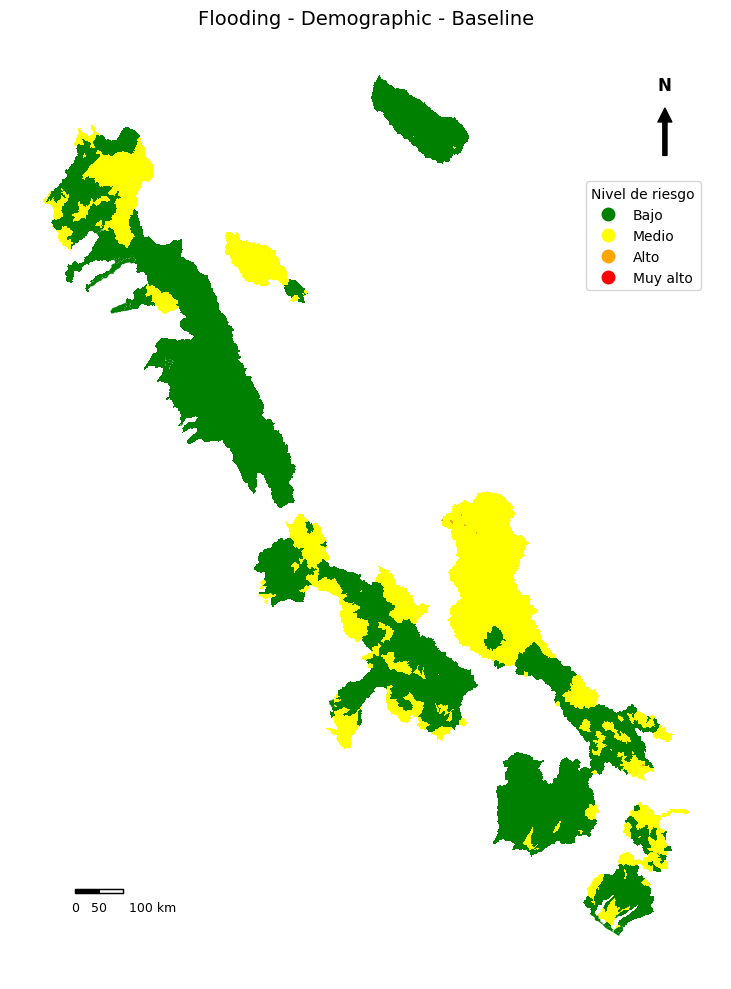

In [38]:
impact_chains = [9, 10, 11]

for ic in impact_chains:
    # Query baseline risk
    baseline_df = get_risk_df(ic, baseline_scnid)

    # Merge with geometry
    baseline_gdf = subbasins_gdf.join(baseline_df, how='left')

    # Classify risk
    baseline_gdf['RiskClass'] = classify_risk_fixed(baseline_gdf['Riesgo'])

    # Get metadata for title
    name, sector = ic_metadata.get(ic, ("Unknown", "Unknown"))
    scenario_name = scenario_names.get(baseline_scnid, str(baseline_scnid))

    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    baseline_gdf.plot(
        column='RiskClass',
        categorical=True,
        legend=True,
        ax=ax,
        cmap=plt.matplotlib.colors.ListedColormap(risk_colors),
        missing_kwds={'color': 'lightgrey', 'label': 'No data'}
    )

    ax.set_title(f"{name} - {sector} - {scenario_name}", fontsize=14)
    ax.set_axis_off()

    # Add cartographic elements
    add_north_arrow(ax)
    add_scale_bar(ax, baseline_gdf)

    # Move legend under north arrow
    legend = ax.get_legend()
    if legend is not None:
        legend.set_bbox_to_anchor((0.98, 0.85))
        legend.set_loc('upper right')
        legend.set_title('Nivel de riesgo')

    plt.tight_layout()
    plt.show()



In [ ]:
# modify to also loop through modeling groups 
# Loop through impact chains and create maps
for ic in impact_chains:
    # Get risk data for baseline and future
    baseline_df = get_risk_df(ic, baseline_scnid)
    future_df = get_risk_df(ic, future_scnid)
    
    # Merge with geodataframe
    baseline_gdf = subbasins_gdf.join(baseline_df, how='left')
    future_gdf = subbasins_gdf.join(future_df, how='left')
    
    # Optional: set same min/max for consistent coloring
    vmin = min(baseline_gdf['Riesgo'].min(), future_gdf['Riesgo'].min())
    vmax = max(baseline_gdf['Riesgo'].max(), future_gdf['Riesgo'].max())
    
    # Plot baseline
    baseline_file = os.path.join(output_path, f"{baseline_scnid}_{ic}.png")
    plot_risk_map(baseline_gdf, 'Riesgo', f"Impact Chain {ic} - Baseline Scenario", baseline_file, vmin=vmin, vmax=vmax)
    
    # Plot future
    future_file = os.path.join(output_path, f"{future_scnid}_{ic}.png")
    plot_risk_map(future_gdf, 'Riesgo', f"Impact Chain {ic} - Future Scenario", future_file, vmin=vmin, vmax=vmax)
    
    # Calculate percent change and plot delta
    delta_gdf = baseline_gdf.copy()
    delta_gdf['Riesgo'] = ((future_gdf['Riesgo'] - baseline_gdf['Riesgo']) / baseline_gdf['Riesgo']) * 100
    delta_file = os.path.join(output_path, f"{ic}_delta.png")
    plot_risk_map(delta_gdf, 'Riesgo', f"Impact Chain {ic} - Percent Change", delta_file, cmap='RdYlBu', vmin=-100, vmax=100)
